In [ ]:
#EDA_방문지, 핵심 타겟

In [ ]:
import sys
!{sys.executable} -m pip install seaborn

In [ ]:
!pip list | grep seaborn

seaborn                           0.13.2


In [ ]:
!pip install seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 경로 및 정확한 파일명 설정
file_path = "/Users/ubi/Downloads/무제 폴더 2/2024년 국민여행조사_해외여행_RAWDATA.xlsx"
# 엑셀 파일 읽기
df = pd.read_excel(file_path, sheet_name=0)

(51755, 923)


,아이디,"공통] A_여행 횟수-6. 1년 이하 해외여행 경험 - 관광/휴양 활동, 가족/친지/친구 방문, 출장/업무 등 모두 포함","공통] A-6_여행경험_1년 이하 해외여행 경험-관광/휴양 활동, 가족/친지/친구 방문, 출장/업무 등 모두 포함",해외] B_여행1차_본설문진행여부,해외] B_여행1차_여행유형,해외] B_여행1차_시작날짜_년,해외] B_여행1차_시작날짜_월,해외] B_여행1차_시작날짜_일,해외] B_여행1차_끝날짜_년,해외] B_여행1차_끝날짜_월,...,해외] 분석변수_1회 평균 여행지출,해외] 분석변수_여행시기_해외여행_평일,해외] 분석변수_여행시기_해외여행_주말,해외] 분석변수_여행시기_해외여행_휴일,해외] 분석변수_여행시기_해외여행_명절연휴,해외] 방문국가1,해외] 방문국가2,해외] 방문국가3,해외] 방문국가4,해외] 방문국가5
0,ID,SA1_6,MON_EXP_6,O_TRA1_CHECK,O_TRA1_CASE,O_TRA1_SYEAR,O_TRA1_SMONTH,O_TRA1_SDAY,O_TRA1_EYEAR,O_TRA1_EMONTH,...,해외_A_1회평균_여행지출,해외_A_해외여행_평일,해외_A_해외여행_주말,해외_A_해외여행_휴일,해외_A_해외여행_명절연휴,해외_방문국가1,해외_방문국가2,해외_방문국가3,해외_방문국가4,해외_방문국가5
1,11010550271_275001,0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11010550271_275003,0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11010550271_275004,0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11010550271_275007,0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


가장 많이 방문한 국가 (Top 10):
157    875
80     524
194    190
161    128
29     127
220     96
223     62
116     47
7       32
222     19
Name: count, dtype: int64


/var/folders/8p/zcr5sw3s0kqf30fmnr1q76nw0000gn/T/ipykernel_9874/792738277.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=most_common_countries.index, y=most_common_countries.values, palette='viridis')


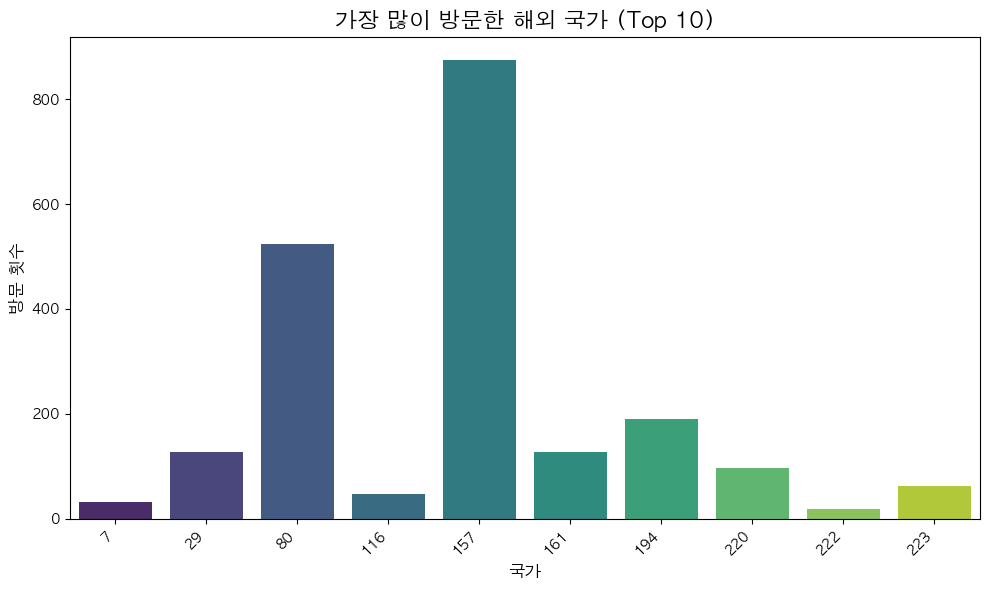

In [ ]:
#해외 관광 여행지
# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic' # macOS users
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

#가장 많이 방문한 국가 분석 및 시각화
visit_cols = [col for col in df.columns if '방문국가' in col]

if visit_cols:
    # 두 컬럼을 합쳐서 value_counts로 최빈값 확인
    most_common_countries = df[visit_cols].stack().value_counts().head(10)

    print("가장 많이 방문한 국가 (Top 10):")
    print(most_common_countries)

    # 시각화
    plt.figure(figsize=(10, 6))
    sns.barplot(x=most_common_countries.index, y=most_common_countries.values, palette='viridis')
    plt.title('가장 많이 방문한 해외 국가 (Top 10)', fontsize=16)
    plt.xlabel('국가', fontsize=12)
    plt.ylabel('방문 횟수', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('most_visited_countries_revised.png')
    plt.show()

else:
    print("경고: '방문국가' 관련 컬럼이 가상 데이터에 존재하지 않아 분석을 수행할 수 없습니다.")

In [ ]:
# => 가장 수요가 많은 일본 관광으로 한정

--- [셀 3] '공통] 연령' 시각화 시작 ---


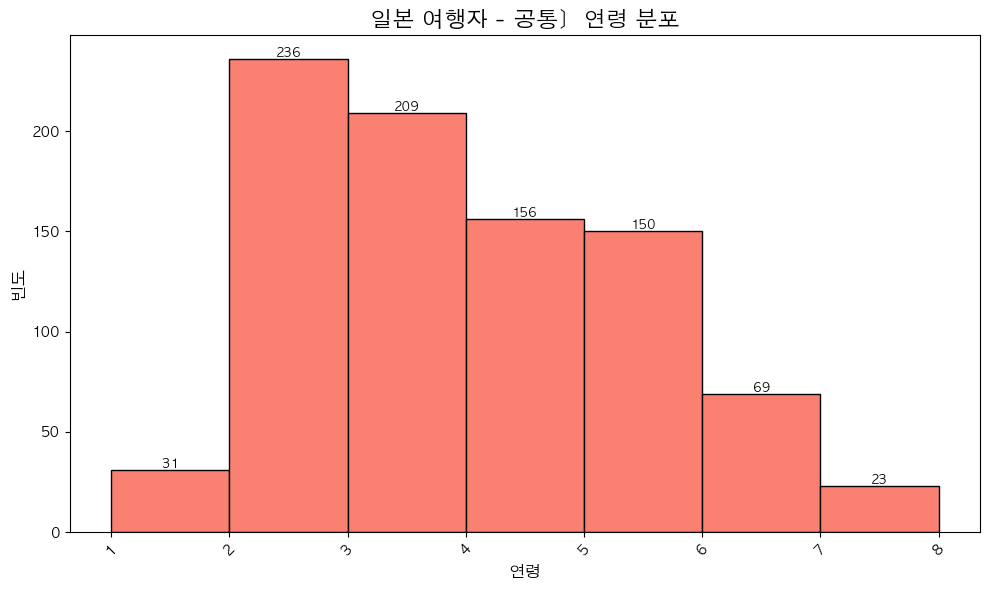

--- [셀 3] '공통] 연령' 시각화 완료 ---


In [ ]:
#연령별 일본 방문
col_name = '공통]  연령' # 시각화할 컬럼명 지정

if 'df_japan' not in globals() or df_japan.empty:
    print("\n경고: 'df_japan' 데이터프레임이 없거나 비어 있어 시각화를 수행할 수 없습니다. 첫 번째 셀을 실행했는지 확인해주세요.")
elif col_name not in df_japan.columns:
    print(f"\n경고: df_japan에 컬럼 '{col_name}'이(가) 없습니다. 컬럼명을 확인해주세요.")
else:
    plt.figure(figsize=(10, 6))
    ax = plt.gca()

    numeric_data = pd.to_numeric(df_japan[col_name], errors='coerce').dropna()

    if numeric_data.empty:
        ax.text(0.5, 0.5, f"'{col_name}' 수치 데이터 없음", ha='center', va='center', transform=ax.transAxes, color='gray', fontsize=16)
        ax.set_title(f'일본 여행자 - {col_name} 분포 (데이터 없음)', fontsize=16)
    else:
        min_val = numeric_data.min()
        max_val = numeric_data.max()
        bins = np.arange(min_val, max_val + 2) if max_val - min_val > 1 else np.linspace(min_val, max_val + 1, 10)

        counts, bins, patches = ax.hist(numeric_data, bins=bins, edgecolor='black', color='salmon')

        ax.set_title(f'일본 여행자 - {col_name} 분포', fontsize=16)
        ax.set_xlabel(col_name.replace('공통]  ', ''), fontsize=12)
        ax.set_ylabel('빈도', fontsize=12)
        ax.set_xticks(bins)
        ax.tick_params(axis='x', rotation=45)

        for count, x_coord, patch in zip(counts, bins[:-1], patches):
            if count > 0:
                ax.text(patch.get_x() + patch.get_width() / 2, patch.get_height(),
                        f'{int(count)}', ha='center', va='bottom', fontsize=9, color='black')

    plt.tight_layout()
    plt.savefig(f'japan_travelers_{col_name.replace("공통]  ", "").replace(" ", "_")}.png')
    plt.show()

print("--- [셀 3] '공통] 연령' 시각화 완료 ---")

--- 일본 여행자 연령대(숫자 코드) 비율 원그래프 시각화 시작 ---


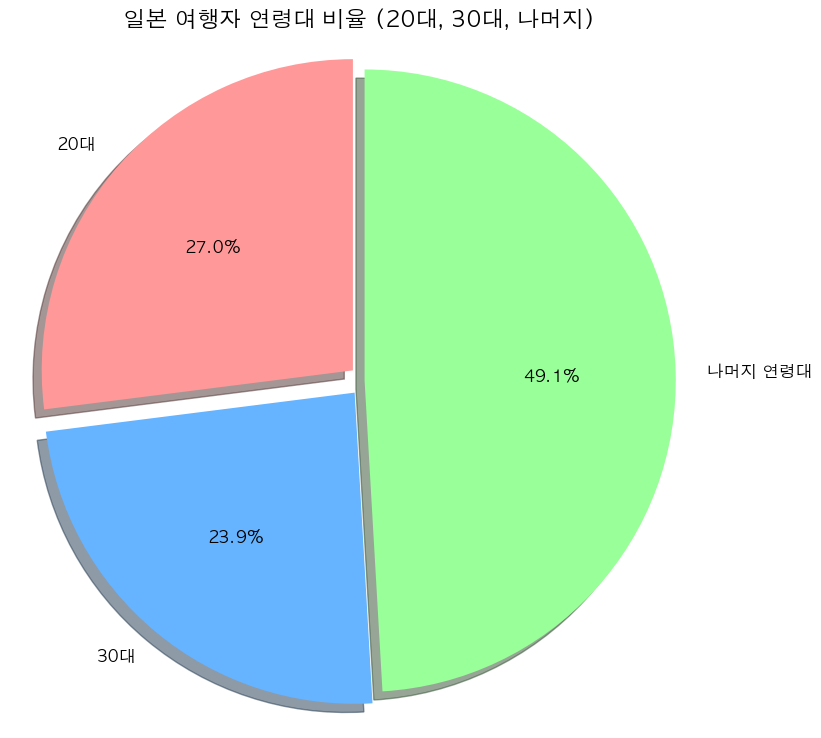


원그래프 시각화가 완료되었습니다.
'japan_travelers_age_groups_by_code_pie_chart.png' 파일을 확인해주세요.


In [ ]:
#=> 20대와 30대, 나머지 연령 비율
age_col_name = '공통]  연령' # 컬럼명 공백 주의 (df_japan의 실제 컬럼명과 일치)

# df_japan 데이터프레임이 존재하는지 확인
if 'df_japan' in locals() or 'df_japan' in globals():
    # '공통]  연령' 컬럼이 데이터프레임에 있는지 확인
    if age_col_name in df_japan.columns:
        # 컬럼의 유효한 값(NaN 제거)만 가져와서 빈도 계산
        valid_age_data = df_japan[age_col_name].dropna()

        if not valid_age_data.empty:
            # 명목형 숫자 코드를 기반으로 그룹화
            count_20s = valid_age_data[valid_age_data == 2].count()
            count_30s = valid_age_data[valid_age_data == 3].count()

            # 나머지 연령대 (코드 1, 4, 5, 6, 7)
            count_others = valid_age_data[valid_age_data.isin([1, 4, 5, 6, 7])].count()

            # 원그래프를 위한 데이터와 라벨 준비
            sizes = [count_20s, count_30s, count_others]
            labels = ['20대', '30대', '나머지 연령대']
            colors = ['#ff9999', '#66b3ff', '#99ff99'] # 각 그룹별 색상
            explode = (0.05, 0.05, 0) # 20대와 30대 부분을 강조하기 위해 약간 분리

            # 모든 그룹의 합이 0인 경우 (데이터가 없거나 필터링 결과가 없는 경우)
            if sum(sizes) == 0:
                print(f"경고: '{age_col_name}' 컬럼에 유효한 연령대 데이터가 없습니다. 원그래프를 생성할 수 없습니다.")
            else:
                # 원그래프 생성
                plt.figure(figsize=(9, 9)) # 그래프 크기 조정
                plt.pie(sizes, explode=explode, labels=labels, colors=colors,
                        autopct='%1.1f%%', shadow=True, startangle=90,
                        textprops={'fontsize': 12, 'color': 'black'}) # 텍스트 속성 추가
                plt.title('일본 여행자 연령대 비율 (20대, 30대, 나머지)', fontsize=16)
                plt.axis('equal')  # 원을 완벽한 원 형태로 유지

                plt.savefig('japan_travelers_age_groups_by_code_pie_chart.png')
                plt.show()

                print("\n원그래프 시각화가 완료되었습니다.")
                print("'japan_travelers_age_groups_by_code_pie_chart.png' 파일을 확인해주세요.")
        else:
            print(f"경고: '{age_col_name}' 컬럼에 유효한 데이터가 없어 원그래프를 생성할 수 없습니다.")
    else:
        print(f"경고: 'df_japan'에 '{age_col_name}' 컬럼이 없어 분석을 수행할 수 없습니다.")
        print("이 코드를 실행하기 전에 'df_japan'이 올바르게 정의되었고 해당 컬럼을 포함하는지 확인해주세요.")
else:
    print("\n경고: 'df_japan' 데이터프레임이 현재 환경에 정의되어 있지 않습니다.")
    print("이 코드를 실행하기 전에 'df_japan'을 먼저 정의해주세요.")

--- 연령대별 1차 여행 1인 지출 비용 시각화 (박스플롯) 시작 ---


/var/folders/8p/zcr5sw3s0kqf30fmnr1q76nw0000gn/T/ipykernel_9874/2343647039.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=age_group_col, y=target_col, order=order, palette='crest')


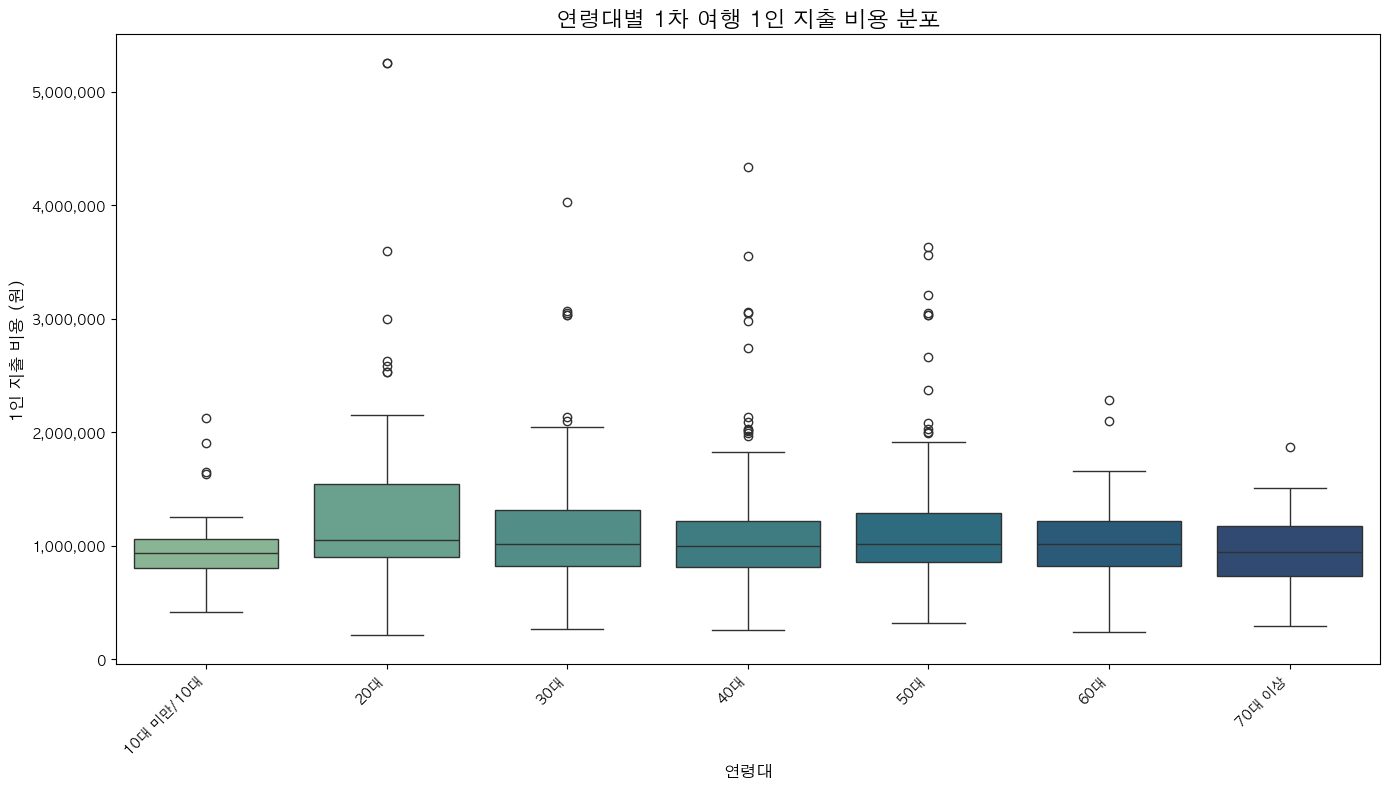

--- 연령대별 1차 여행 1인 지출 비용 시각화 완료 ---


In [ ]:
#연령별 지출 금액
# 한글 폰트 설정 (macOS용)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지


print("--- 연령대별 1차 여행 1인 지출 비용 시각화 (박스플롯) 시작 ---")

# --- 1. 필요한 컬럼 정의 ---
target_col = '해외]  B_여행1차_1인지출비용'
age_group_col = '연령대_범주형'

# df_japan 데이터프레임 존재 및 필수 컬럼 확인
if 'df_japan' not in globals() or df_japan.empty:
    print("\n경고: 'df_japan' 데이터프레임이 없거나 비어 있어 시각화를 수행할 수 없습니다.")
elif age_group_col not in df_japan.columns:
    print(f"\n경고: '{age_group_col}' 컬럼이 없습니다. 연령대 컬럼이 생성되었는지 확인해주세요.")
elif target_col not in df_japan.columns:
    print(f"\n경고: 'df_japan'에 '{target_col}' 컬럼이 없습니다. 컬럼명을 확인해주세요.")
else:
    # 2. 데이터 전처리 및 준비
    plot_df = df_japan.dropna(subset=[target_col, age_group_col]).copy()

    if plot_df.empty:
        print(f"경고: '{target_col}' 데이터가 유효하지 않아 시각화할 수 없습니다.")
    else:
        # '1인 지출 비용' 컬럼을 숫자형으로 변환
        plot_df[target_col] = pd.to_numeric(plot_df[target_col], errors='coerce')
        plot_df.dropna(subset=[target_col], inplace=True)

        if plot_df.empty:
            print(f"경고: '1인 지출 비용' 컬럼에 유효한 수치형 데이터가 없어 시각화할 수 없습니다.")
        else:
            # 3. 시각화 (박스플롯)
            plt.figure(figsize=(14, 8))

            # 연령대 순서 (이전에 정의된 age_order_for_plot이 있다면 사용)
            if 'age_order_for_plot' in globals():
                order = age_order_for_plot
            else:
                order = sorted(plot_df[age_group_col].unique())

            sns.boxplot(data=plot_df, x=age_group_col, y=target_col, order=order, palette='crest')

            plt.title('연령대별 1차 여행 1인 지출 비용 분포', fontsize=16)
            plt.xlabel('연령대', fontsize=12)
            plt.ylabel('1인 지출 비용 (원)', fontsize=12)
            plt.xticks(rotation=45, ha='right')

            # Y축 포맷을 원화로 변경
            plt.ticklabel_format(style='plain', axis='y')
            plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

            plt.tight_layout()
            plt.savefig('japan_travelers_expenditure_by_age_boxplot.png')
            plt.show()

    print("--- 연령대별 1차 여행 1인 지출 비용 시각화 완료 ---")